# Práctica Machine Learning - Predicción de precios Airbnb - Diana Ospina

En esta práctica se construirá un modelo de regresión para predecir el precio de alojamientos de Airbnb a partir de las características del anuncio.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

Cargamos el dataset

In [2]:
import pandas as pd

df = pd.read_csv(
    "C:/Users/Usuario/Documents/Capacitación Keepcoding/MACHINE LEARNING/machine-learning/project/airbnb-listings-extract.csv",
    sep=";"
)

df.head()


,ID,Listing Url,Scrape ID,Last Scraped,Name,Summary,Space,Description,Experiences Offered,Neighborhood Overview,...,Review Scores Communication,Review Scores Location,Review Scores Value,License,Jurisdiction Names,Cancellation Policy,Calculated host listings count,Reviews per Month,Geolocation,Features
0,11210388,https://www.airbnb.com/rooms/11210388,20170306202425,2017-03-07,The Loft-Full Bath-Deck w/View,Loft in the Hill country 12-15 minutes directl...,This loft has a spectacular view of the hills ...,Loft in the Hill country 12-15 minutes directl...,none,This neighborhood is located in the hills west...,...,10.0,10.0,10.0,NaN,NaN,moderate,1.0,3.50,"30.3373609355,-97.8632766782","Host Is Superhost,Host Has Profile Pic,Host Id..."
1,17471131,https://www.airbnb.com/rooms/17471131,20170407214050,2017-04-08,"Claris I, Friendly Rentals","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...",none,Plaza Cataluña Catalonia Square is the large...,...,10.0,8.0,10.0,HUTB-006721,NaN,super_strict_30,106.0,0.86,"41.3896829422,2.17262543017","Host Has Profile Pic,Requires License,Instant ..."
2,17584891,https://www.airbnb.com/rooms/17584891,20170407214050,2017-04-08,"Style Terrace Red, Friendly Rentals","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...","This apartment has: 1 double bed, 1 double sof...",none,Plaza Cataluña Catalonia Square is the large...,...,NaN,NaN,NaN,HUTB-007527,NaN,super_strict_30,106.0,NaN,"41.3930345489,2.16217327868","Host Has Profile Pic,Requires License,Instant ..."
3,5398030,https://www.airbnb.com/rooms/5398030,20170407214050,2017-04-08,Picasso Suite 1.4 Paseo de Gracia,Live like a local in Barcelona's most chic dis...,You wake up to the sun rising over Barcelona's...,Live like a local in Barcelona's most chic dis...,none,We're right in the heart of the chic L'Eixampl...,...,10.0,10.0,9.0,NaN,NaN,strict,24.0,1.09,"41.3969668101,2.1674178103","Host Has Profile Pic,Host Identity Verified,Re..."
4,18104606,https://www.airbnb.com/rooms/18104606,20170407214050,2017-04-08,Smart City Centre Apartment II,"Unique apartment in vibrant neighborhoods, car...","License: HUTB-005313 Charming apartment, locat...","Unique apartment in vibrant neighborhoods, car...",none,NaN,...,NaN,NaN,NaN,NaN,NaN,flexible,92.0,NaN,"41.3886851936,2.15514963616","Host Has Profile Pic,Host Identity Verified,Is..."


Análisis exploratorio

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14780 entries, 0 to 14779
Data columns (total 89 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              14780 non-null  int64  
 1   Listing Url                     14780 non-null  object 
 2   Scrape ID                       14780 non-null  int64  
 3   Last Scraped                    14780 non-null  object 
 4   Name                            14779 non-null  object 
 5   Summary                         14189 non-null  object 
 6   Space                           10888 non-null  object 
 7   Description                     14774 non-null  object 
 8   Experiences Offered             14780 non-null  object 
 9   Neighborhood Overview           9134 non-null   object 
 10  Notes                           5644 non-null   object 
 11  Transit                         9066 non-null   object 
 12  Access                          

,ID,Scrape ID,Host ID,Host Response Rate,Host Listings Count,Host Total Listings Count,Latitude,Longitude,Accommodates,Bathrooms,...,Number of Reviews,Review Scores Rating,Review Scores Accuracy,Review Scores Cleanliness,Review Scores Checkin,Review Scores Communication,Review Scores Location,Review Scores Value,Calculated host listings count,Reviews per Month
count,1.478000e+04,1.478000e+04,1.478000e+04,12881.000000,14777.000000,14777.000000,14780.000000,14780.000000,14780.000000,14725.000000,...,14780.000000,11476.000000,11454.000000,11460.000000,11443.000000,11460.000000,11440.000000,11439.000000,14776.000000,11618.000000
mean,1.028089e+07,2.017037e+13,3.608080e+07,94.823461,12.513636,12.513636,40.497626,-3.858041,3.277808,1.281732,...,22.632273,91.697978,9.416012,9.328883,9.621778,9.647033,9.532168,9.218201,9.486871,1.870014
std,5.564829e+06,5.667971e+08,3.425360e+07,15.215988,34.090223,34.090223,4.641387,14.123146,2.097291,0.658517,...,38.290244,8.989101,0.921938,0.989933,0.802736,0.767116,0.774527,0.950578,23.626014,1.867550
min,1.862800e+04,2.016010e+13,1.745300e+04,0.000000,0.000000,0.000000,-37.851182,-123.131344,1.000000,0.000000,...,0.000000,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,0.020000
25%,5.554732e+06,2.017041e+13,6.787360e+06,100.000000,1.000000,1.000000,40.409726,-3.707604,2.000000,1.000000,...,1.000000,89.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,1.000000,0.450000
50%,1.133492e+07,2.017041e+13,2.464875e+07,100.000000,2.000000,2.000000,40.419466,-3.700785,3.000000,1.000000,...,7.000000,94.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,2.000000,1.200000
75%,1.532631e+07,2.017041e+13,5.432919e+07,100.000000,6.000000,6.000000,40.430916,-3.684057,4.000000,1.000000,...,27.000000,98.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,5.000000,2.780000
max,1.910969e+07,2.017062e+13,1.247534e+08,100.000000,519.000000,519.000000,55.966912,153.371427,16.000000,8.000000,...,446.000000,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,145.000000,17.210000


El dataset contiene aproximadamente 14.780 registros de alojamientos con múltiples variables descriptivas del anuncio, del anfitrión y de la ubicación.

La variable Host Response Rate muestra valores muy altos, con una mediana del 100%, lo que indica que la mayoría de anfitriones responde a casi todas las solicitudes.

la latitud y longitud promedio son de ubicaciones aproximadamente en la zona de Madrid

Preparemos los datos 

In [4]:
df.dtypes

ID                                  int64
Listing Url                        object
Scrape ID                           int64
Last Scraped                       object
Name                               object
                                   ...   
Cancellation Policy                object
Calculated host listings count    float64
Reviews per Month                 float64
Geolocation                        object
Features                           object
Length: 89, dtype: object

In [5]:
df.isna().sum().sort_values(ascending=False).head(20)

Has Availability         14768
Host Acceptance Rate     14741
Jurisdiction Names       14553
License                  14431
Square Feet              14182
Monthly Price            11219
Weekly Price             11190
Notes                     9136
Security Deposit          8524
Interaction               6554
Access                    6462
Cleaning Fee              6093
Transit                   5714
Neighborhood Overview     5646
Host About                5241
Neighbourhood             5229
House Rules               5161
Space                     3892
Host Neighbourhood        3876
Review Scores Value       3341
dtype: int64

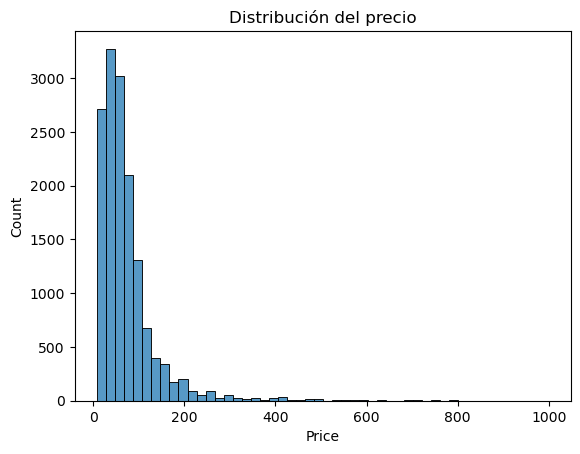

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Price"], bins=50)
plt.title("Distribución del precio")
plt.show()

In [7]:
df.columns

Index(['ID', 'Listing Url', 'Scrape ID', 'Last Scraped', 'Name', 'Summary',
       'Space', 'Description', 'Experiences Offered', 'Neighborhood Overview',
       'Notes', 'Transit', 'Access', 'Interaction', 'House Rules',
       'Thumbnail Url', 'Medium Url', 'Picture Url', 'XL Picture Url',
       'Host ID', 'Host URL', 'Host Name', 'Host Since', 'Host Location',
       'Host About', 'Host Response Time', 'Host Response Rate',
       'Host Acceptance Rate', 'Host Thumbnail Url', 'Host Picture Url',
       'Host Neighbourhood', 'Host Listings Count',
       'Host Total Listings Count', 'Host Verifications', 'Street',
       'Neighbourhood', 'Neighbourhood Cleansed',
       'Neighbourhood Group Cleansed', 'City', 'State', 'Zipcode', 'Market',
       'Smart Location', 'Country Code', 'Country', 'Latitude', 'Longitude',
       'Property Type', 'Room Type', 'Accommodates', 'Bathrooms', 'Bedrooms',
       'Beds', 'Bed Type', 'Amenities', 'Square Feet', 'Price', 'Weekly Price',
       'Month

In [8]:
df["Price"].head()

0     58.0
1     70.0
2     70.0
3    229.0
4    149.0
Name: Price, dtype: float64

In [9]:
df["Price"].dtype

dtype('float64')

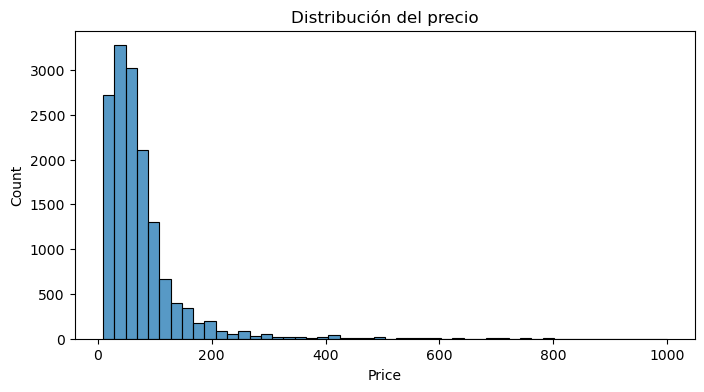

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df["Price"], bins=50)
plt.title("Distribución del precio")
plt.show()

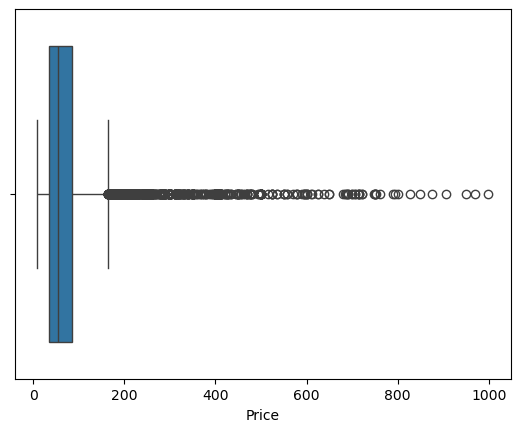

In [11]:
sns.boxplot(x=df["Price"])
plt.show()

In [12]:
df.shape

(14780, 89)

El dataset contiene aproximadamente 14.780 observaciones y 89 variables que describen características del alojamiento, del anfitrión y de la ubicación.

In [13]:
df.dtypes.value_counts()

object     53
float64    23
int64      13
Name: count, dtype: int64

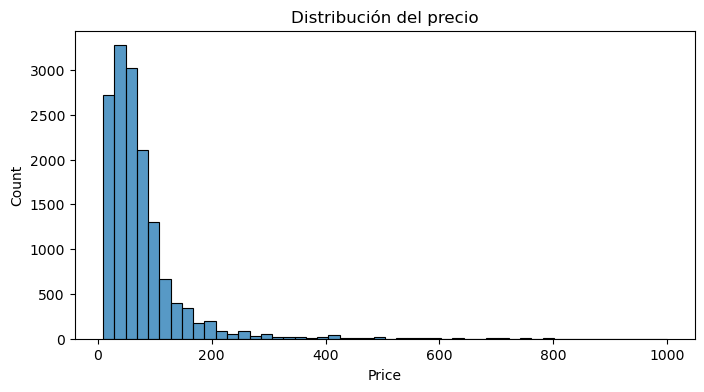

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df["Price"], bins=50)
plt.title("Distribución del precio")
plt.show()

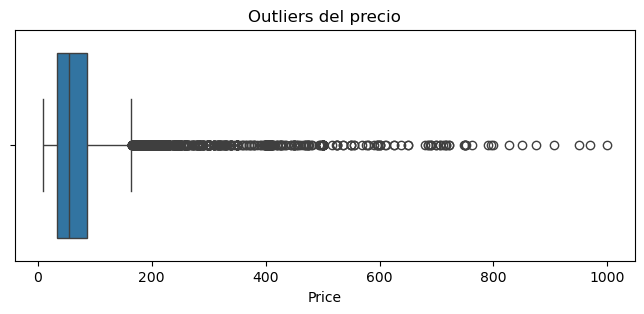

In [15]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df["Price"])
plt.title("Outliers del precio")
plt.show()

In [16]:
q_low = df["Price"].quantile(0.01)
q_high = df["Price"].quantile(0.99)

df = df[(df["Price"] >= q_low) & (df["Price"] <= q_high)]

eliminamos valores extremos utilizando los percentiles 1% y 99% para reducir el impacto de los outliers

In [17]:
missing = df.isna().sum().sort_values(ascending=False)
missing.head(20)

Has Availability         14463
Host Acceptance Rate     14439
Jurisdiction Names       14255
License                  14127
Square Feet              13886
Monthly Price            10950
Weekly Price             10906
Notes                     8935
Security Deposit          8283
Interaction               6375
Access                    6291
Cleaning Fee              5888
Transit                   5541
Neighborhood Overview     5484
Host About                5104
Neighbourhood             5069
House Rules               5045
Space                     3763
Host Neighbourhood        3753
Review Scores Value       3194
dtype: int64

In [18]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct.sort_values(ascending=False).head(20)

Has Availability         99.917098
Host Acceptance Rate     99.751295
Jurisdiction Names       98.480138
License                  97.595855
Square Feet              95.930915
Monthly Price            75.647668
Weekly Price             75.343696
Notes                    61.727116
Security Deposit         57.222798
Interaction              44.041451
Access                   43.461140
Cleaning Fee             40.677029
Transit                  38.279793
Neighborhood Overview    37.886010
Host About               35.260794
Neighbourhood            35.018998
House Rules              34.853195
Space                    25.996546
Host Neighbourhood       25.927461
Review Scores Value      22.065630
dtype: float64

In [19]:
cols_missing = missing_pct[missing_pct > 50].index
df = df.drop(columns=cols_missing)

Se eliminaron variables con mas de 50% de valores faltantes para evitar ruido

Se eliminan columnas que no ayudan al modelo 

In [20]:
cols_drop = [
"ID","Listing Url","Scrape ID","Host ID",
"Thumbnail Url","Medium Url","Picture Url","XL Picture Url",
"Host URL","Host Thumbnail Url","Host Picture Url"
]

df = df.drop(columns=[c for c in cols_drop if c in df.columns])

In [21]:
df.shape

(14475, 69)

Tras el proceso de limpieza se eliminaron el número de variables eliminando columnas con alto porcentaje de valroes faltantes que no aportan info relevante

In [22]:
X = df.drop(columns=["Price"])
y = df["Price"]

División train/test

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
X_train.shape, X_test.shape

((11580, 68), (2895, 68))

80% train y 20% test - 11580 + 2895 = 1445 registros

El conjunto de entrenamiento contiene 11.580 observaciones mientras que el conjunto de prueba contiene 2.895 observaciones. Esta separación permite evaluar el desempeño del modelo en datos no utilizados durante el entrenamiento.

Ahora preparemos los datos para el modelo, sepamos variables numericas y categóricas

In [25]:
numeric_features = X_train.select_dtypes(include=np.number).columns
categorical_features = X_train.select_dtypes(exclude=np.number).columns

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", len(categorical_features))

Variables numéricas: 28
Variables categóricas: 40


In [26]:
numeric_features

Index(['Host Response Rate', 'Host Listings Count',
       'Host Total Listings Count', 'Latitude', 'Longitude', 'Accommodates',
       'Bathrooms', 'Bedrooms', 'Beds', 'Cleaning Fee', 'Guests Included',
       'Extra People', 'Minimum Nights', 'Maximum Nights', 'Availability 30',
       'Availability 60', 'Availability 90', 'Availability 365',
       'Number of Reviews', 'Review Scores Rating', 'Review Scores Accuracy',
       'Review Scores Cleanliness', 'Review Scores Checkin',
       'Review Scores Communication', 'Review Scores Location',
       'Review Scores Value', 'Calculated host listings count',
       'Reviews per Month'],
      dtype='object')

In [27]:
categorical_features

Index(['Last Scraped', 'Name', 'Summary', 'Space', 'Description',
       'Experiences Offered', 'Neighborhood Overview', 'Transit', 'Access',
       'Interaction', 'House Rules', 'Host Name', 'Host Since',
       'Host Location', 'Host About', 'Host Response Time',
       'Host Neighbourhood', 'Host Verifications', 'Street', 'Neighbourhood',
       'Neighbourhood Cleansed', 'Neighbourhood Group Cleansed', 'City',
       'State', 'Zipcode', 'Market', 'Smart Location', 'Country Code',
       'Country', 'Property Type', 'Room Type', 'Bed Type', 'Amenities',
       'Calendar Updated', 'Calendar last Scraped', 'First Review',
       'Last Review', 'Cancellation Policy', 'Geolocation', 'Features'],
      dtype='object')

Separamos variables numéricas y categóricas

In [28]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", len(categorical_features))

Variables numéricas: 28
Variables categóricas: 40


Baseline

In [29]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [30]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [31]:
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Host Response Rate',
                                                   'Host Listings Count',
                                                   'Host Total Listings Count',
                                                   'Latitude', 'Longitude',
                                                   'Accommodates', 'Bathrooms',
                                                   'Bedrooms', 'Beds',
                                                   'Cleaning Fee',
                                                   'Guests Included',
                                                   'Extra People',
                                                   'Minimum Ni...
                                                   'Transit', 'Access',
                                                   'Interaction', 'House Rules',
                                                   'Host Name', 'Host Since',
                                                   'Host Location',
                                                   'Host About',
                                                   'Host Response Time',
                                                   'Host Neighbourhood',
                                                   'Host Verifications',
                                                   'Street', 'Neighbourhood',
                                                   'Neighbourhood Cleansed',
                                                   'Neighbourhood Group '
                                                   'Cleansed',
                                                   'City', 'State', 'Zipcode',
                                                   'Market', 'Smart Location',
                                                   'Country Code', 'Country',
                                                   'Property Type', ...])])),
                ('model', LinearRegression())])

In [32]:
y_pred_baseline = baseline_model.predict(X_test)

In [33]:
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = mean_squared_error(y_test, y_pred_baseline) ** 0.5
r2_baseline = r2_score(y_test, y_pred_baseline)

print("Baseline - Linear Regression")
print("MAE:", mae_baseline)
print("RMSE:", rmse_baseline)
print("R2:", r2_baseline)

Baseline - Linear Regression
MAE: 17.893369406771225
RMSE: 27.17193709134709
R2: 0.7195811813541506


En promedio el modelo se equivoca 17,9 unidades de precio, con el RMSE muestra que el modelo tiene algunos errores grandes pero no tanto por la cercanía de MAE y R2= el modelo explica el 71,9% de la variabilidad del precio

Comparación de modelos

In [34]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=30,
        random_state=42,
        n_jobs=-1
    )
}

In [35]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [36]:
results = []

for name, model in models.items():
    
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    mae_cv = -cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_absolute_error"
    ).mean()
    
    results.append({
        "modelo": name,
        "MAE_CV": mae_cv
    })

results_df = pd.DataFrame(results).sort_values("MAE_CV")

results_df

,modelo,MAE_CV
2,RandomForest,16.527994
1,Ridge,19.124729
0,LinearRegression,19.256082


Random Forest con MAE de 16.53 es el mejor modelo porque tiene el menor error,  funciona mejor con muchas variables categóricas lo que indica un mejor desempeño en la pedicción del precio de los alojamientos.  El Ridge mejora ligeramente la regresión lineas porque tiene regularización y reduce el overfitting

Modelo final 

In [37]:
best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=30,
        random_state=42,
        n_jobs=-1
    ))
])

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)
print("R2:", r2_score(y_test, y_pred))

MAE: 15.413264248704664
RMSE: 26.212210646007737
R2: 0.7390404148908083


En promedio el modelo se equivoca 15,4 unidades de precio y explica el 73,9% de variabilida del precio

Importancia de las variables

In [38]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
7,num__Bedrooms,0.281726
6,num__Bathrooms,0.145693
84837,cat__Room Type_Entire home/apt,0.085003
9,num__Cleaning Fee,0.048866
3,num__Latitude,0.023075
5,num__Accommodates,0.018465
17,num__Availability 365,0.012526
4,num__Longitude,0.011805
83987,cat__State_马德里自治区,0.011353
27,num__Reviews per Month,0.010276


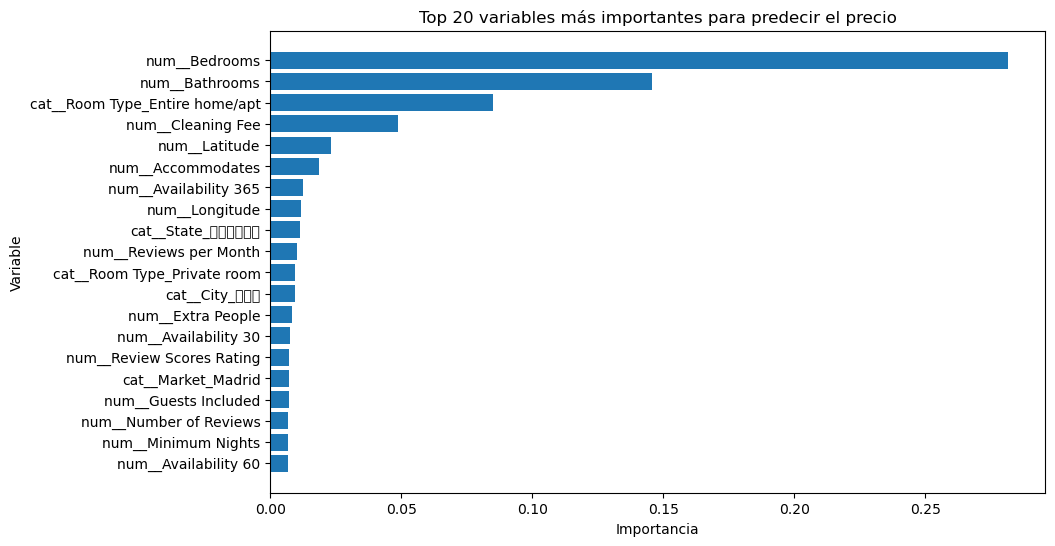

In [39]:
import warnings
warnings.filterwarnings("ignore")

top20 = importance_df.head(20).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top20["feature"], top20["importance"])
plt.title("Top 20 variables más importantes para predecir el precio")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

las variables mas importantes fueron: Bedrooms, Bathrooms, Romm Type. Cleaning Fee( tarifa de limpieza), Ubicación, Accommodates (capacidad)

Se analizó la importancia de las variables utilizando el modelo Random Forest

CONCLUSIONES

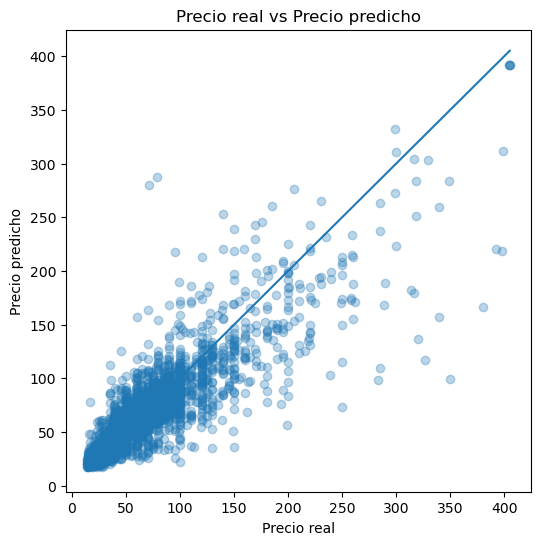

In [40]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Precio real vs Precio predicho")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.show()

El gráfico muestra la relación entre el precio real  y el precio que predice el modelo. La proximidad de los puntos a la línea diagonal indica que el moldeo es capaz de ralizar predicciones razonablemente precisas.

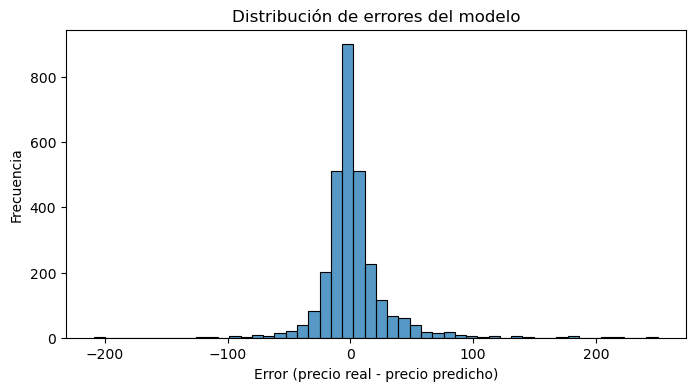

In [41]:
errors = y_test - y_pred

plt.figure(figsize=(8,4))
sns.histplot(errors, bins=50)

plt.title("Distribución de errores del modelo")
plt.xlabel("Error (precio real - precio predicho)")
plt.ylabel("Frecuencia")

plt.show()

Centro en 0, es un buen modelo y los errores relativamente pequeños y centrados

Conclusiones: Se compararon modelos de regresión para predecir el precio de alojamientos en Airbnb.
Random Forest obtuvo el mejor desempeño con un MAE de aprox 15 unidades monetarias y un R2 de 0.74, superando a los modelos lineales.
Las variables más influyentes en la predicción fueron el número de habitaciones, número de baños, tipo de alojamiento y ubicación geográfica.
En la práctica un anfitrion puede saber cuánto cobrar por noche, la empresa puede usar el modelo para sugerir precios dinámicos, detectar precios muy altos o bajos y mejorar la competitividad


Como ejemplo el modelo a continuación recibe un solo alojamiento y estima su precio

In [42]:
ejemplo = X_test.iloc[[0]]

best_model.predict(ejemplo)

array([22.16666667])